In [2]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt

# Connect SQLite Database
conn = sqlite3.connect("student_database.db")

# Load CSV into DataFrame
df = pd.read_csv('/content/drive/MyDrive/student_performance.csv')

# Store dataframe into SQL table
df.to_sql("students", conn, if_exists="replace", index=False)

print("Database Connected Successfully")

Database Connected Successfully


In [3]:
query1 = """
SELECT department,
AVG(math_score) AS avg_math_score
FROM students
GROUP BY department
"""

avg_math_df = pd.read_sql_query(query1, conn)

print(avg_math_df)

         department  avg_math_score
0             Civil       63.400000
1  Computer Science       85.615385
2       Electronics       71.000000
3        Mechanical       71.000000


In [4]:
query2 = """
SELECT department,
COUNT(*) AS student_count
FROM students
GROUP BY department
"""

dept_count_df = pd.read_sql_query(query2, conn)

print(dept_count_df)

         department  student_count
0             Civil              5
1  Computer Science             13
2       Electronics              6
3        Mechanical              6


In [7]:
query3 = """
SELECT name,
department,
(math_score + science_score + english_score) AS total_score
FROM students
ORDER BY total_score DESC
LIMIT 8
"""

top_students_df = pd.read_sql_query(query3, conn)

print(top_students_df)

             name        department  total_score
0      Ananya Das  Computer Science          274
1     Tanvi Mehta  Computer Science          271
2  Akanksha Yadav  Computer Science          271
3     Divya Singh  Computer Science          263
4  Swati Kulkarni  Computer Science          262
5      Arjun Nair  Computer Science          261
6    Ritu Agarwal       Electronics          256
7       Amit Bose  Computer Science          247


In [8]:
query4 = """
SELECT gender,
AVG(attendance_percentage) AS avg_attendance
FROM students
GROUP BY gender
"""

gender_attendance_df = pd.read_sql_query(query4, conn)

print(gender_attendance_df)

   gender  avg_attendance
0  Female       88.533333
1    Male       80.466667


# MATPLOTLIB DASHBOARD

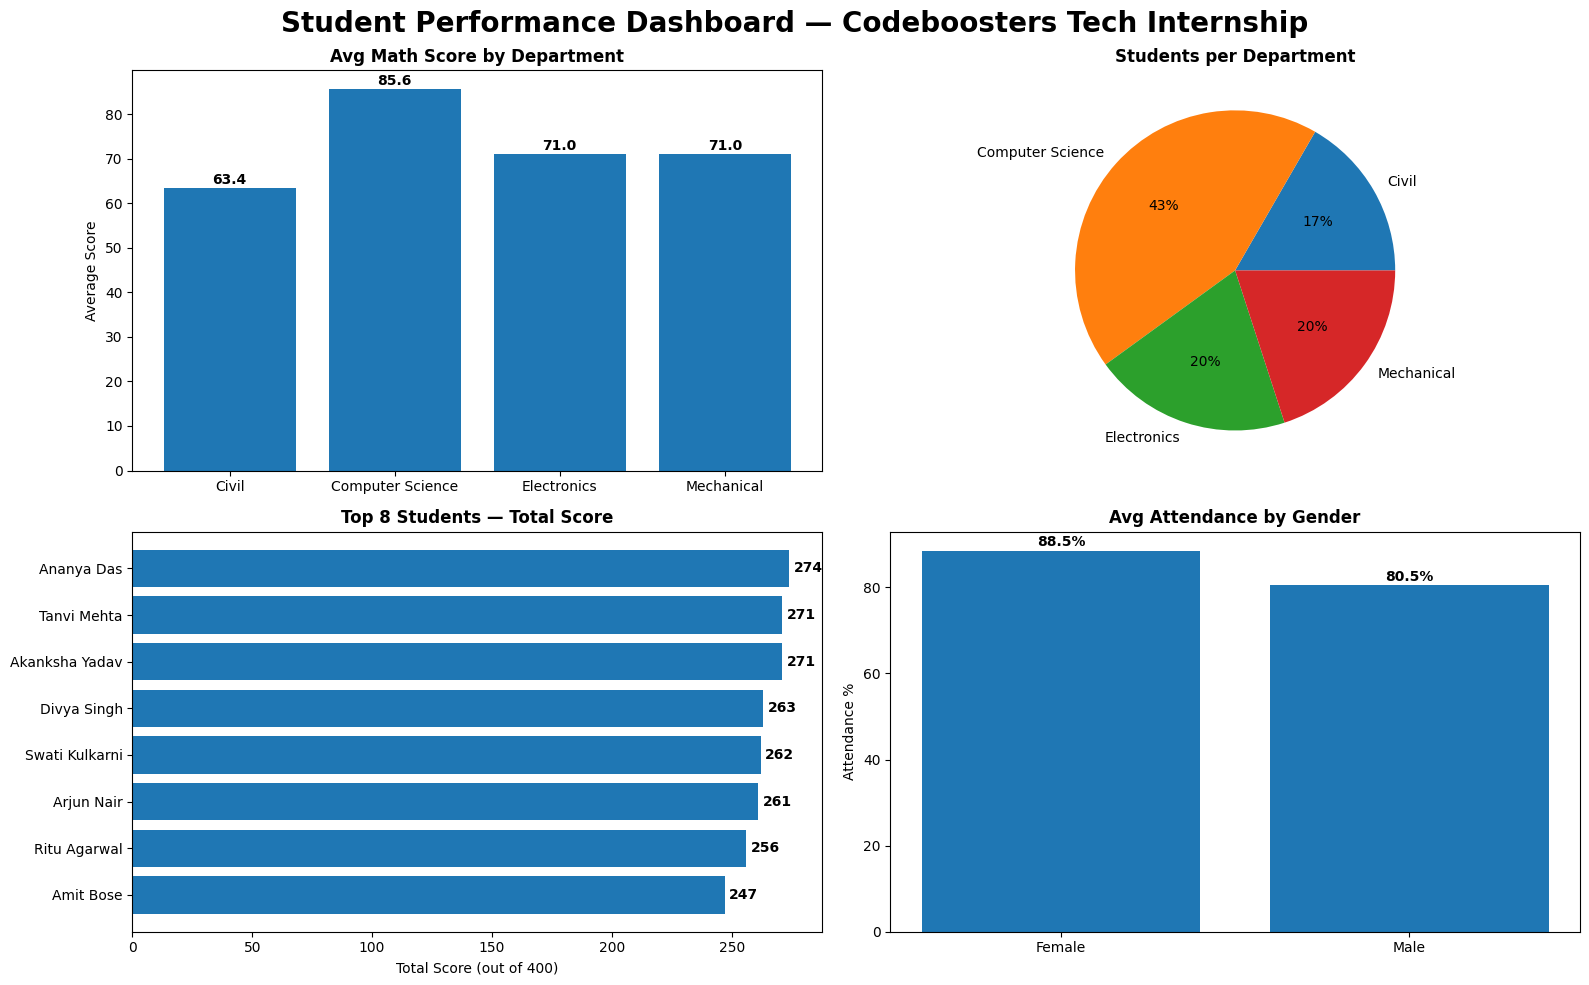

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

fig.suptitle(
    "Student Performance Dashboard — Codeboosters Tech Internship",
    fontsize=20,
    fontweight='bold'
)

# ======================================================
# Panel 1 (Top Left)
# Avg Math by Department - BAR CHART
# ======================================================

axes[0,0].bar(
    avg_math_df['department'],
    avg_math_df['avg_math_score']
)

axes[0,0].set_title("Avg Math Score by Department", fontweight='bold')
axes[0,0].set_ylabel("Average Score")

# Add values on bars
for i, value in enumerate(avg_math_df['avg_math_score']):
    axes[0,0].text(i, value + 1, f"{value:.1f}", ha='center', fontweight='bold')

# ======================================================
# Panel 2 (Top Right)
# Student Count Pie Chart
# ======================================================

axes[0,1].pie(
    dept_count_df['student_count'],
    labels=dept_count_df['department'],
    autopct='%1.0f%%'
)

axes[0,1].set_title("Students per Department", fontweight='bold')

# ======================================================
# Panel 3 (Bottom Left)
# Top 8 Students Horizontal Bar
# ======================================================

axes[1,0].barh(
    top_students_df['name'],
    top_students_df['total_score']
)

axes[1,0].invert_yaxis()

axes[1,0].set_title("Top 8 Students — Total Score", fontweight='bold')
axes[1,0].set_xlabel("Total Score (out of 400)")

# Add values on bars
for i, value in enumerate(top_students_df['total_score']):
    axes[1,0].text(value + 2, i, str(value), va='center', fontweight='bold')

# ======================================================
# Panel 4 (Bottom Right)
# Gender Avg Attendance Bar
# ======================================================

axes[1,1].bar(
    gender_attendance_df['gender'],
    gender_attendance_df['avg_attendance']
)

axes[1,1].set_title("Avg Attendance by Gender", fontweight='bold')
axes[1,1].set_ylabel("Attendance %")

# Add values on bars
for i, value in enumerate(gender_attendance_df['avg_attendance']):
    axes[1,1].text(i, value + 1, f"{value:.1f}%", ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

# PRACTICE QUESTIONS

In [10]:
query_q1 = """
SELECT AVG(programming_score) AS avg_programming_score
FROM students
WHERE gender = 'Female'
"""

result_q1 = pd.read_sql_query(query_q1, conn)

print(result_q1)

   avg_programming_score
0                   70.2


In [11]:
# WHERE filters rows BEFORE grouping

query_where = """
SELECT *
FROM students
WHERE math_score > 80
"""

where_result = pd.read_sql_query(query_where, conn)

print("WHERE Example")
print(where_result.head())

WHERE Example
   student_id          name  age  gender        department  semester  \
0        1001  Aarav Sharma   19    Male  Computer Science         2   
1        1005    Arjun Nair   19    Male  Computer Science         2   
2        1008   Divya Singh   19  Female  Computer Science         2   
3        1010    Ananya Das   19  Female  Computer Science         2   
4        1013    Suresh Rao   21    Male  Computer Science         2   

   math_score  science_score  english_score  programming_score  \
0          85             78             72                 91   
1          92             88             81                 95   
2          88             91             84                 93   
3          95             89             90                 97   
4          83             86             77                 88   

   attendance_percentage     city  admission_year  
0                     92   Mumbai            2023  
1                     90    Kochi            2023  


In [12]:
# HAVING filters groups AFTER grouping

query_having = """
SELECT department,
AVG(math_score) AS avg_math
FROM students
GROUP BY department
HAVING AVG(math_score) > 75
"""

having_result = pd.read_sql_query(query_having, conn)

print("HAVING Example")
print(having_result)

HAVING Example
         department   avg_math
0  Computer Science  85.615385


In [13]:
query_q3 = """
SELECT department,
AVG(attendance_percentage) AS avg_attendance
FROM students
GROUP BY department
HAVING AVG(attendance_percentage) > 85
"""

result_q3 = pd.read_sql_query(query_q3, conn)

print(result_q3)

         department  avg_attendance
0  Computer Science       90.692308


In [14]:
print("""
pd.read_sql_query() returns:
--------------------------------
A Pandas DataFrame

Required Arguments:
--------------------------------
1. SQL Query
2. Database Connection Object

Example:
pd.read_sql_query(query, conn)
""")


pd.read_sql_query() returns:
--------------------------------
A Pandas DataFrame

Required Arguments:
--------------------------------
1. SQL Query
2. Database Connection Object

Example:
pd.read_sql_query(query, conn)



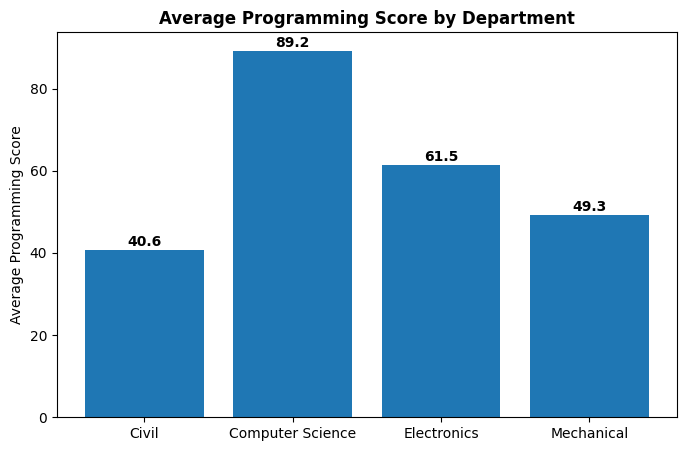

In [15]:
query_prog = """
SELECT department,
AVG(programming_score) AS avg_programming_score
FROM students
GROUP BY department
"""

prog_df = pd.read_sql_query(query_prog, conn)

plt.figure(figsize=(8,5))

plt.bar(
    prog_df['department'],
    prog_df['avg_programming_score']
)

plt.title("Average Programming Score by Department", fontweight='bold')
plt.ylabel("Average Programming Score")

# Add values on bars
for i, value in enumerate(prog_df['avg_programming_score']):
    plt.text(i, value + 1, f"{value:.1f}", ha='center', fontweight='bold')

plt.show()